In [1]:
using Pkg
Pkg.activate(joinpath(dirname(dirname(@__DIR__))))
#Pkg.update()
# If Sunny library is not installed
# using Pkg
# Pkg.add("Sunny")

  Activating project at `/mnt/graphene/home/jalil2/Documents/Projects2026/TDNEGF`


In [2]:
## Main modules 
using TDNEGF
using DifferentialEquations
using LinearAlgebra

println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 1


In [78]:
### Initiallize params for electrons 
function init_params(;Nx::Int=2, Ny::Int=2, Nσ::Int=2, N_orb::Int=1,
                     γ::Float64=1.0, γso=0.1 + 0.0im,Nα = 2, 
                     N_λ1::Int=49, N_λ2::Int=20, β::Float64=33.0)
    ### Get the poles 
    Rλ, zλ = load_poles_square(N_λ1, N_λ2)
    ####Note that we can initiallize the system only with the dimension of the system 
    p = ModelParamsTDNEGF(Nx   = Nx, Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, #### dimension
                          Nα   = Nα,  N_λ1 = N_λ1, N_λ2 = N_λ2 ) ;
    ### Now we can assign the real initial values 
    H_ab    = build_H_ab(;Nx = p.Nx,Ny = p.Ny, Nσ = p.Nσ, N_orb = p.N_orb, γ = γ, γso = γso)
    Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0) ;
    Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0) ;
    χ_nλ    = build_χ_nλ(zλ, p.Ny, p.Nσ, p.N_orb, p.N_λ1, p.N_λ2; β=β, γ=1.0)
    ξ_anR   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = p.Nx,y_coup = 1:p.Ny)
    ξ_anL   = build_ξ_an(p.Nx, p.Ny, p.Nσ, p.N_orb; xcol = 1,y_coup = 1:p.Ny)
    #### Asigning initial values of the precalculated things
    p.H_ab             .= H_ab
    p.H0_ab            .= H_ab
    p.Δ_α              .= [0.0,0.0] 
    #### Self energies
    p.Σᴸ_nλα[:,:,1]    .= Σᴸ_nλ
    p.Σᴸ_nλα[:,:,2]    .= Σᴸ_nλ
    p.Σᴳ_nλα[:,:,1]    .= Σᴳ_nλ
    p.Σᴳ_nλα[:,:,2]    .= Σᴳ_nλ
    Γ_nλα = 1im*copy(p.Σᴳ_nλα - p.Σᴸ_nλα)
    p.Γ_nλα    .= Γ_nλα
    #1im*(p.Σᴳ_nλα - p.Σᴸ_nλα)
    #### Exponent from poles in the residue theorem 
    p.χ_nλα[:,:,1]     .= χ_nλ
    p.χ_nλα[:,:,2]     .= χ_nλ
    #### Channel vectors 
    p.ξ_anα[:,:,1]     .= ξ_anL
    p.ξ_anα[:,:,2]     .= ξ_anR;
    ####
    p.χ′_nλα  .= conj.(p.χ_nλα)
    p.Σᴸ′_nλα .= conj.(p.Σᴸ_nλα)
    p.Γ′_nλα  .= conj.(p.Γ_nλα);
    return p
end ;

In [79]:
using Sunny
### Initiallize params for classical spin (Note that sunny.jl package is used)
function init_params_heisenberg_llg(;Nx::Int=2,Ny::Int=2,j_ex::Float64=0.1,a0::Float64=1.0)
    latvecs   = lattice_vectors(a0, a0, 2*a0, 90, 90, 90)  # cúbica
    positions = [[0.5, 0.5, 0.0]] 
    # Define the symmtery of the crystal 
    cryst = Crystal(latvecs, positions)
    # Characterizes a effective spin magnetic moment on an atom
    # specification of spi moments
    moments = [1 => Moment(s=1.0, g=1.0)]
    # creates an instance of spin moments
    sys = System(cryst, moments, :dipole; dims=(Nx, Ny, 1)) 
    # Heisenberg interaction 
    set_exchange!(sys, j_ex, Bond(1, 1, [1, 0, 0]))  # vecino +x
    set_exchange!(sys, j_ex, Bond(1, 1, [0, 1, 0]))  # vecino +y
    sys = to_inhomogeneous(sys)
    remove_periodicity!(sys, (true, true, true)) 
    ### Initial state
    if j_ex >= 0.0 #(+ is antiferro)
        for I in eachindex(sys.dipoles)
            i,j=ij_from_linear(I,Ny)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, (-1)^(i+j) )  
        end
    else  #(- is ferro)
        for I in eachindex(sys.dipoles)
            
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, 1.0)  ### AFM configuration
        end
    end

    return sys
end

@inline linear_index(i::Int, j::Int, Ny::Int) = (i - 1) * Ny + j

@inline function ij_from_linear(l::Int, Ny::Int)
    i = (l - 1) ÷ Ny + 1
    j = (l - 1) % Ny + 1
    return i, j
end
### Update the classical Hamiltonian
function update_H_s!(Nx::Int,Ny::Int,sys::System{0},σx_i::Array{Float64, 2}, j_sd::Float64 )
    @inbounds for i in 1:Nx for j in 1:Ny
        idx = linear_index(i,j,Ny)
        sden = -σx_i[idx,:]*j_sd
        set_field_at!(sys, sden ,(i , j, 1, 1)) 
        #println(i,j)
    end end
    return nothing 
end
# # sys = init_params_heisenberg_llg(j_ex=0.1)
# sys = init_params_heisenberg_llg(Nx = 2 ,Ny = 2, j_ex = 0.1)
# sys.dipoles

update_H_s! (generic function with 1 method)

In [80]:
#p = init_params()

In [81]:
#p.N_sites

In [82]:
function spin_dynamics_and_electrons_evolution(t_0::Float64, Δt::Float64 ,t_end::Float64;j_sd::Float64 = 0.1, j_ex::Float64 = 0.1)
    println("Join the Main function")
    p   = init_params()
    sys = init_params_heisenberg_llg(Nx = 2 ,Ny = 2, j_ex = j_ex)
    
    p.Δ_α     .= [0.0,-0.0] 
    ### Setting the integrator for electrons
    prob       =  ODEProblem(eom_tdnegf!,p.u, (t_0,t_end), p )
    intg       =  init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)#, reltol=1e-6, abstol=1e-8)#, verbose= true)
    integ      = Langevin(Δt ; damping=0.2, kT=0.0) 
    println("The integrator has been set")
    N_steps      = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p; N_tmax=N_steps , N_leads = p.Nα)
    site_ranges_couple = [get_sub(i, p.N_loc) for i in 1:p.N_sites]#[5,6,7,8]]
    ### Setting the initial Barrier
    # for i in [collect(1:2p.Ny) ; collect(p.Ny*p.Nx-2p.Ny:p.Ny*p.Nx)]
    #     ### Time independent hamiltonian
    #     p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*50
    #     ### Time dependent hamiltonian
    #     p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)]  .= I(2)*50
    # end
    obs.t = collect(t_0:Δt:(t_end-Δt))
    ### loop evolution 
    @time for (i,t) in enumerate(t_0:Δt:(t_end-Δt))
        obs.idx = i
        println("time: ", round(i*Δt,digits=2))
        flush(stdout)
        ## Initial time evolution 
        DifferentialEquations.step!(intg, Δt, true)
        Sunny.step!(sys,integ)

        ### Non_equilibirum Variables 
        dv =  TDNEGF.pointer(intg.u ,p)  
        ### Equilibrium Variables 
        ρ  = ρ_eq(0.0, 33.0, p.H_ab, p.N_λ2,p.Nx,p.Ny,p.Nσ,p.N_orb)

        ### Non_equilibrium observables
        obs_n_i!(dv, p, obs)            ### Charge density
        obs_σ_i!(dv, p, obs)            ### Spin density 
        obs_Ixα!(dv, p, obs)            ### Spin and charge current
        obs_s_i!(sys.dipoles[:,:,1,1], p, obs)
        ### Equilibrium observables 
        obs_σ_i_eq!(ρ, p, obs)

        ### Update Hamitonians
        update_H_s!(p.Nx,p.Ny,sys,obs.σx_i[:,:,obs.idx], j_sd*0.0)           ### Update the Hamiltonian  of classical dynamics
        update_H_e!(p, site_ranges_couple, sys.dipoles[:,:,1,1], j_sd)   ### Update the Hamiltonian electron dynamics 

        # if t ≈ 50.0 # Turn off Barrier
        #     println("Turn off Barrier")
        #     for i in [collect(1:2p.Ny) ; collect(p.Ny*p.Nx-2p.Ny:p.Ny*p.Nx)]
        #         p.H0_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
        #         p.H_ab[get_sub(i, p.N_loc),get_sub(i, p.N_loc)] .= I(2)*0.0
        #     end
        # end

        # if t ≈ 150.0 # Turn off bias voltage
        #     println("Turn off bias voltage")
        #     p.Δ_α     .= [0.0, 0.0]
        # end
        
    end #end evolution loop 
    return  obs
end

spin_dynamics_and_electrons_evolution (generic function with 1 method)

In [83]:
obs = spin_dynamics_and_electrons_evolution(0.0,0.1,200.0; j_ex = -0.05,j_sd = 0.1) #(+ is antiferro /- is ferro)

Join the Main function
The integrator has been set
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 9.5

ObservablesTDNEGF{Float64}([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9  …  199.0, 199.1, 199.2, 199.3, 199.4, 199.5, 199.6, 199.7, 199.8, 199.9], [0.009949960029416 0.03920562273102785 … 0.999969918856948 0.9999700240256242; 0.009949960029415991 0.03920562194391124 … 0.9999700801390313 0.999970184409067; 0.009949960029416 0.03920562194391125 … 0.9999700801390312 0.9999701844090669; 0.009949960029415991 0.03920562273102783 … 0.999969918856948 0.9999700240256242], [6.0292419499192346e-5 6.70633645562788e-12 1.0014931479604416e-8; -6.0292419499192394e-5 6.706336464300096e-12 -1.0014931480471778e-8; 6.029241949919236e-5 -6.70633647328102e-12 -1.0014931479604416e-8; -6.029241949919238e-5 -6.706336472729146e-12 1.0014931480471778e-8;;; 0.0004690186036624969 -4.653792847848647e-6 7.529225636980497e-6; -0.00046899642509176166 4.655285869589442e-6 6.912322310127783e-6; 0.0004689964250917616 -4.655285869589493e-6 6.912322310106966e-6; -0.00046901860366249713 4.6537928478485705e-6 7.5292256

In [69]:
#typeof(obs_AFM.sx_i)

In [70]:
#size(obs_AFM.sx_i)

In [84]:
using PyPlot
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs=25

25

In [498]:
### Lets plot the AFM against the FM configuration 
# Calculation of the average magnetization for FM configuration
function avg_M(dip::Array{Float64, 3},Nx::Int,Ny::Int)
    size_t   = size(dip)[3]
    size_sys = Nx*Ny#size(dip)[1]
    M_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            for x in 1:3
                M_t[x,t_idx] +=  dip[i ,x,t_idx]
            end
        end
    end
    return M_t/size_sys
end
# Calculation of the average Neel Vector for AFM configuration
function avg_N(dip::Array{Float64, 3},Nx::Int,Ny::Int)
                
    size_t   = size(dip)[3]
    size_sys = Nx*Ny
    N_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            i_x,j_y = ij_from_linear(i,Ny)
            for x in 1:3
                N_t[x,t_idx] +=  dip[i ,x,t_idx]*(-1)^(i_x+j_y)
            end
        end
    end
    return N_t/size_sys

end

avg_N (generic function with 2 methods)

In [85]:
#obs_AFM.sx_i

In [86]:
#N = avg_N(obs_AFM.sx_i,2,2)

In [11]:
# plt.plot(obs_AFM.t,N[1,:])
# plt.plot(obs_AFM.t,N[2,:])
# plt.plot(obs_AFM.t,N[3,:])

In [12]:
# fig,axs =  plt.subplots(2,2)

# axs[1,1].set_ylabel(raw"$\mathrm{N^{\alpha}}$", fontsize = fs)
# axs.plot(obs_FM.t,obs_AFM.sx_i[1,1,:],color = "red")
# #axs.plot(obs_FM.t,obs_AFM.sx_i[2,1,:],color = "blue")

# axs[1,2].set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)


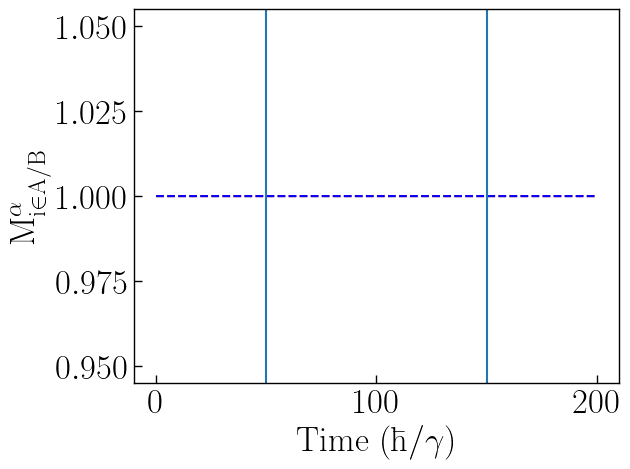

In [87]:

fig,axs =  plt.subplots(1,1)
site = 3
sites = range(1,2)
# for site in sites
#    # obs2.t .+obs.t[end]
#     axs.plot(obs.t,obs.sx_i[site,1,:])#,alpha =1-0.2*i ) ### Charge bound current
#     #axs.plot(obs.t,obs.sx_i[site,2,:],label= raw"$\alpha=y$ ")
#     #axs.plot(obs.t,obs.sx_i[site,3,:],label= "site=$(site)")
#    # axs.plot(obs2.t .+obs.t[end],obs2.sx_i[site,3,:],label= raw"$\alpha=z$ ")
# end
# axs.plot(obs_AFM.t,obs_AFM.sx_i[1,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[2,1,:],color = "blue")

# axs.plot(obs_AFM.t,obs_AFM.sx_i[3,1,:],color = "red")
# axs.plot(obs_AFM.t,obs_AFM.sx_i[4,1,:],color = "blue")

# axs.plot(obs.t,obs.sx_i[1,2,:],color = "red",ls = ":")
# axs.plot(obs.t,obs.sx_i[2,2,:],color = "blue",ls = ":")

axs.plot(obs.t,obs.sx_i[1,3,:],color = "red",ls = "--")
axs.plot(obs.t,obs.sx_i[2,3,:],color = "blue",ls = "--")

#axs.plot(obs_AFM.t,obs_AFM.sx_i[4,3,:],color = "red",ls = "--")

# axs.plot(obs.t,obs.sx_i[3,3,:],color = "red",ls = "-")
# axs.plot(obs.t,obs.sx_i[4,3,:],color = "blue",ls = "-")
# line1 = plt.plot([0, 1], [0, 1], color="red",ls="-")[1]
# line2 = plt.plot([0, 1], [1, 0], color="blue",ls="-")[1]
# line3 = plt.plot([0, 1], [1, 0], color="black",ls="-")[1]
# line4 = plt.plot([0, 1], [1, 0], color="black",ls="--")[1]
# lg2 = axs.legend([line1, line2, line3, line4], [raw"$\rm{i \in A}$", raw"$\rm{i \in B}$", raw"$\rm{\alpha=x}$", raw"$\rm{\alpha=z}$"]
#                 ,frameon = false, fontsize = fs-10, loc= (0.05,  0.9),ncol =4,columnspacing=0.5)
# axs.add_artist(lg2)

axs.set_ylabel(raw"$\mathrm{M^{\alpha}_{i \in A/B}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
axs.axvline(50)
axs.axvline(150)
#plt.xlim(0,150)
#axs.text(x=0.08, y=0.1, s = raw"$\mathrm{Vb}$",fontsize=fs-2,ha="center", transform=axs.transAxes,color="gray")
#plt.xlim(0,500)
#plt.ylim(-1.5,1.3)
plt.tight_layout()

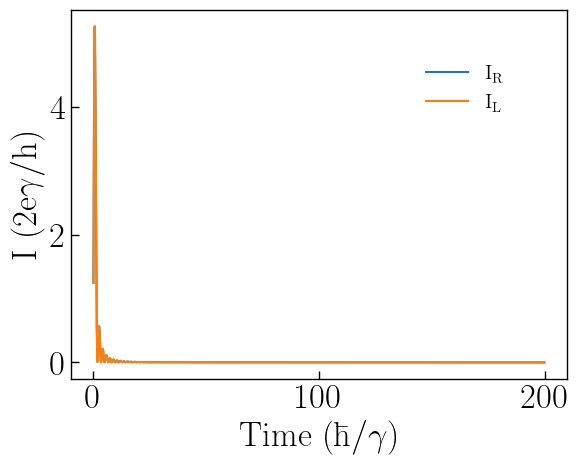

PyObject <matplotlib.legend.Legend object at 0x7fafda3caa50>

In [88]:
fig,axs = plt.subplots(1,1)
axs.plot(obs.t,obs.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
axs.plot(obs.t,obs.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
#axs.plot(obs.t,obs.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")


# axs.plot(obs2.t .+obs.t[end],obs2.Iα[1,:]*pi, label = raw"$\mathrm{I_R}$")  ### Units of 2e/h 
# axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi, label = raw"$\mathrm{I_L}$")
#axs.plot(obs2.t .+obs.t[end],obs2.Iα[2,:]*pi .+ obs.Iα[1,:]*pi , label = raw"$\mathrm{I_T}$")
#axs.axhline(1)
#axs.axhline(-0.1)

axs.set_ylabel(L"$\mathrm{I\ (2e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))

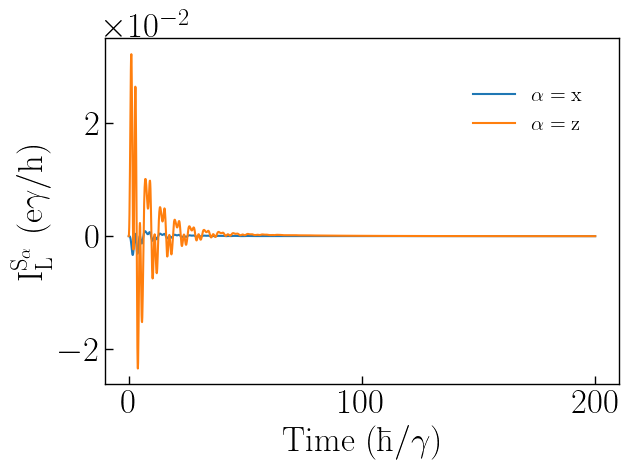

In [89]:
fig,axs = plt.subplots(1,1)
axs.plot(obs.t,obs.Iαx[2,1,:], label = raw"$\mathrm{\alpha = x}$")
#axs.plot(obs_AFM.t,obs_AFM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.plot(obs.t,obs.Iαx[2,3,:], label = raw"$\mathrm{\alpha = z}$")

#axs.plot(obs_AFM.t,obs_AFM.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(obs2.t .+obs.t[end],obs2.Iαx[1,3,:], label = raw"$\mathrm{\alpha = z}$")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")

#axs.plot(obs.t,obs.Iαx[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.axhline(0.08)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))
#axs.set_ylim(-2e-1,2e-1)
#axs.set_ylim(-2e-5,2e-5)
#plt.xlim(0,200)
plt.tight_layout()

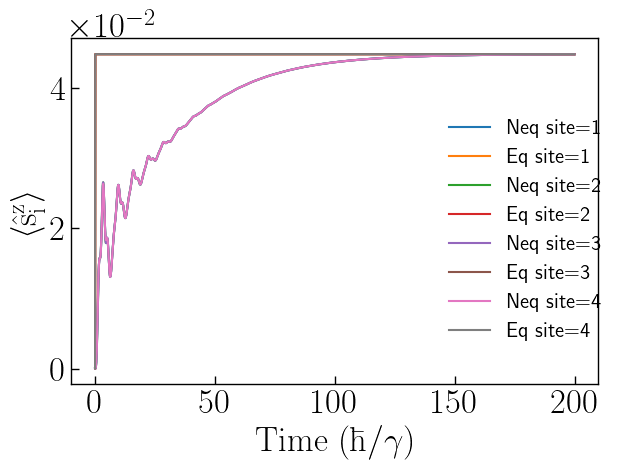

In [92]:


fig,axs =  plt.subplots(1,1)
site = 1
sites = 1:4#2:2:12#range(1,4)
for site in sites
    
    #axs.plot(obs2.t,obs2.σx_i[site,1,:],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(obs.t,obs.σx_i[site,2,:],label= raw"$\alpha=y$ ")
    axs.plot(obs.t,obs.σx_i[site,3,:],label= "Neq site=$(site)")
    axs.plot(obs.t,obs.σx_i_eq[site,3,:],label= "Eq site=$(site)")
    #axs.plot(obs2.t .+obs.t[end],obs2.σx_i[site,3,:],label= raw"$\alpha=z$ ")
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{s}^{z}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (\hbar/\gamma)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(200,300)
plt.tight_layout()